In [0]:
%pip install sentence-transformers

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Databricks notebook source
# MAGIC %md
# MAGIC # Semantic Chunking of PDF Documents - End-to-End Implementation
# MAGIC This script demonstrates semantic chunking using LangChain's SemanticChunker to intelligently split PDF documents based on semantic similarity.

# COMMAND ----------

# Step 1: Install Required Libraries
%pip install -q langchain langchain-experimental langchain-openai langchain-community langchain-text-splitters pypdf sentence-transformers chromadb matplotlib seaborn numpy plotly


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install -q pymupdf tqdm

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from tqdm import tqdm


In [0]:
# COMMAND ----------

# Step 2: Import Required Libraries
import os
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Dict
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# LangChain imports
# NOTE: In Databricks, PyMuPDFLoader works with local-style paths:
#   - DBFS:    "/dbfs/mnt/your-mount/file.pdf"
#   - Volumes: "/Volumes/catalog/schema/volume/file.pdf"
# Do NOT use "dbfs:/" prefix — use "/dbfs/" (FUSE mount) instead.
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [0]:
# COMMAND ----------

# CONFIGURE YOUR PDF PATH HERE
# For Databricks, use a DBFS path or a Volume path, e.g.:
#   pdfs_path = "/dbfs/mnt/your-mount/pdfs"
#   pdfs_path = "/Volumes/catalog/schema/volume/pdfs"
pdfs_path = "/Volumes/vgpd/fsr_std_views/fsr_std_vol/FSR_After_2016/FSR_Databricks/"  # <-- UPDATE THIS PATH

# COMMAND ----------

# Step 3: Load and Analyze PDF Structure
pdf_files = [f for f in os.listdir(pdfs_path) if f.endswith('.pdf')]
print(f"Found {len(pdf_files)} PDF files")
print(f"Sample files: {pdf_files[:5]}")

# COMMAND ----------

def analyze_pdf_structure(pdf_path):
    """Analyze the structure of a single PDF"""
    try:
        loader = PyMuPDFLoader(pdf_path)
        pages = loader.load()
        return {
            'filename': os.path.basename(pdf_path),
            'num_pages': len(pages),
            'total_characters': sum(len(page.page_content) for page in pages),
            'avg_chars_per_page': np.mean([len(page.page_content) for page in pages]) if pages else 0,
            'content_sample': pages[0].page_content[:300] if pages else "",
            'metadata_sample': pages[0].metadata if pages else {}
        }
    except Exception as e:
        return {
            'filename': os.path.basename(pdf_path),
            'error': str(e)
        }

print("Analyzing PDF structures...")
pdf_analyses = []
for pdf_file in tqdm(pdf_files[:30], desc="Analyzing PDFs"):
    pdf_path = os.path.join(pdfs_path, pdf_file)
    analysis = analyze_pdf_structure(pdf_path)
    pdf_analyses.append(analysis)

df_analysis = pd.DataFrame(pdf_analyses)
print("\n📊 PDF Structure Analysis:")
print(df_analysis[['filename', 'num_pages', 'total_characters', 'avg_chars_per_page']].to_string())

# COMMAND ----------

# Display sample content from first PDF
print("\n📄 Sample Content from First PDF:")
print("=" * 80)
if pdf_analyses and 'content_sample' in pdf_analyses[0]:
    print(pdf_analyses[0]['content_sample'])
    print("=" * 80)
    print(f"\nMetadata: {pdf_analyses[0].get('metadata_sample', {})}")

# COMMAND ----------

# Step 4: Initialize Embeddings Model
print("Initializing embeddings model...")

# SSL workaround (uncomment if needed on your Databricks cluster)
# import ssl
# os.environ['CURL_CA_BUNDLE'] = ''
# os.environ['REQUESTS_CA_BUNDLE'] = ''
# ssl._create_default_https_context = ssl._create_unverified_context

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'}
)

print("✓ Embeddings model initialized successfully!")



Found 230 PDF files
Sample files: ['00004423-9ebe-46e9-ac88-b0d096699d3d.pdf', '0000475b-c650-485f-9b36-69ef691dd7ed.pdf', '00092826-716a-40a8-9c5f-ce307465a87f.pdf', '000966e2-b88b-459c-8966-e2b88be59c9d.pdf', '005375e0-631f-41bf-9375-e0631f91bf90.pdf']
Analyzing PDF structures...


Analyzing PDFs:  60%|██████    | 18/30 [00:41<00:23,  1.95s/it]

MuPDF error: format error: cannot find page 4 in page tree



Analyzing PDFs: 100%|██████████| 30/30 [01:05<00:00,  2.19s/it]



📊 PDF Structure Analysis:
                                    filename  num_pages  total_characters  avg_chars_per_page
0   00004423-9ebe-46e9-ac88-b0d096699d3d.pdf        271            229790          847.933579
1   0000475b-c650-485f-9b36-69ef691dd7ed.pdf         54             67824         1256.000000
2   00092826-716a-40a8-9c5f-ce307465a87f.pdf        216            241551         1118.291667
3   000966e2-b88b-459c-8966-e2b88be59c9d.pdf         60             17444          290.733333
4   005375e0-631f-41bf-9375-e0631f91bf90.pdf         15             13992          932.800000
5   0092023d-b13c-428c-9202-3db13cc28cbf.pdf        306            189728          620.026144
6   021decdb-873f-43be-9dec-db873f53bebd.pdf         71             70401          991.563380
7   02a29a81-c142-42f0-a29a-81c14282f00b.pdf        394            363058          921.467005
8   02ce6abc-f707-4603-8e6a-bcf707f60329.pdf         69             78495         1137.608696
9   033fdd55-a5d5-46fa-bfdd-55a5d

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Embeddings model initialized successfully!


In [0]:

# COMMAND ----------

# Step 5: Initialize Different Semantic Chunkers
semantic_chunker_percentile = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=95
)

semantic_chunker_std = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="standard_deviation",
    breakpoint_threshold_amount=1.5
)

semantic_chunker_iqr = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="interquartile",
    breakpoint_threshold_amount=1.5
)

# Traditional character-based splitter for comparison
traditional_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len
)

print("✓ All chunking strategies initialized!")

# COMMAND ----------

# Step 6: Apply Chunking to Sample PDF
sample_pdf = os.path.join(pdfs_path, pdf_files[0])
print(f"Loading PDF: {pdf_files[0]}")

loader = PyMuPDFLoader(sample_pdf)
documents = loader.load()

full_text = "\n\n".join([doc.page_content for doc in documents])
print(f"Total document length: {len(full_text)} characters")
print(f"Number of pages: {len(documents)}")

# COMMAND ----------

# Apply all chunking strategies
print("\n🔄 Applying chunking strategies...")

chunks_traditional = traditional_splitter.split_documents(documents)
print(f"✓ Traditional (Character-based): {len(chunks_traditional)} chunks")

chunks_percentile = semantic_chunker_percentile.split_documents(documents)
print(f"✓ Semantic (Percentile): {len(chunks_percentile)} chunks")

chunks_std = semantic_chunker_std.split_documents(documents)
print(f"✓ Semantic (Std Dev): {len(chunks_std)} chunks")

chunks_iqr = semantic_chunker_iqr.split_documents(documents)
print(f"✓ Semantic (IQR): {len(chunks_iqr)} chunks")



✓ All chunking strategies initialized!
Loading PDF: 00004423-9ebe-46e9-ac88-b0d096699d3d.pdf
Total document length: 230330 characters
Number of pages: 271

🔄 Applying chunking strategies...
✓ Traditional (Character-based): 309 chunks
✓ Semantic (Percentile): 538 chunks
✓ Semantic (Std Dev): 307 chunks
✓ Semantic (IQR): 286 chunks



📊 Chunking Strategies Comparison:
             Strategy  Total Chunks  Avg Chunk Size    Std Dev  Min Size  Max Size  Median Size
   Traditional (Char)           309      764.288026 148.248232        13       999        785.0
Semantic (Percentile)           538      424.269517 332.971582         3      2860        372.5
   Semantic (Std Dev)           307      744.260586 288.455898         3      2860        777.0
       Semantic (IQR)           286      798.982517 336.629483         3      2928        779.5


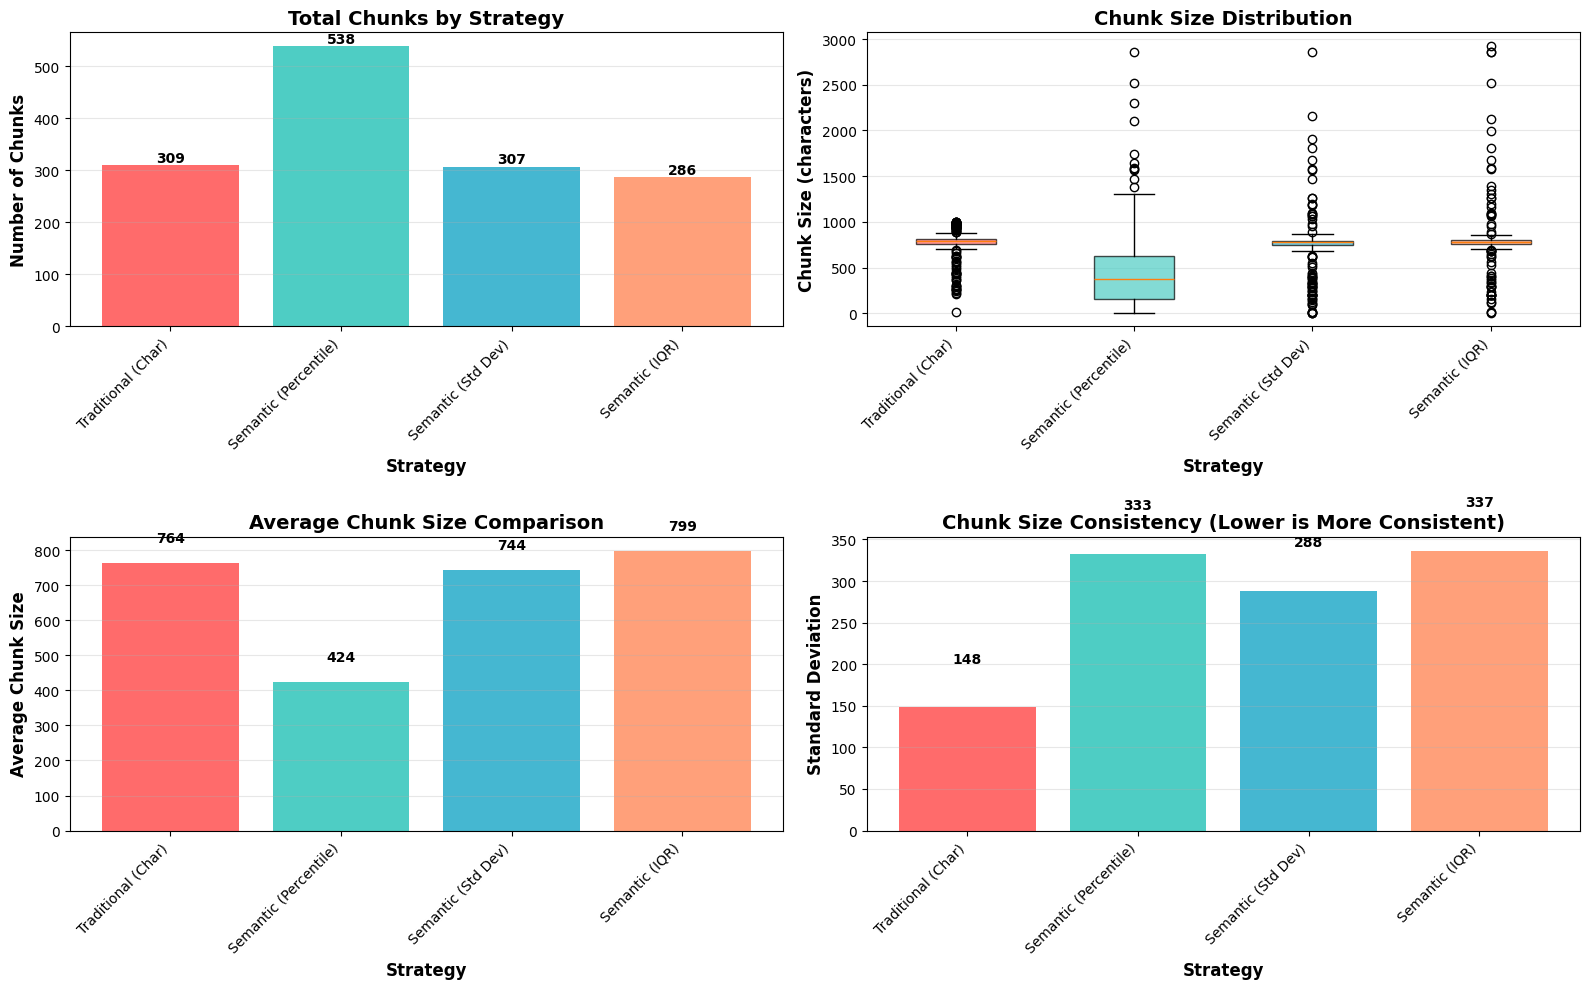


📋 Traditional Character-Based Chunking - Sample Chunks

--- Chunk 1 (Length: 912 chars) ---
GT1B - Fall 2024 Outage
Enhanced Borescope Inspection and Unplanned 
Work
Apex Generating Station
 
Outage Start Date: 29 Oct 2024
Outage End Date: 26 Nov 2024
ESN/SY: 297837 | SY0069758
Oracle Project ID: A-1823120 | EV-153666 | EVP-535936
Prepared By
Jacob Coker
Field Engineer ( TFA ) (FC)
© 2024, GE Vernova. GE Vernova Confidential Information - This document contains GE Vernova proprietary inf...


--- Chunk 2 (Length: 313 chars) ---
approval to do so. If consent is given for reproduction in whole or in part, this notice and the notice set forth on each page of this document shall appear in 
any such reproduction. The information contained in this document may also be controlled by the US export control laws. Unauthorized export or re-export


📋 Semantic Chunking (Percentile) - Sample Chunks

--- Chunk 1 (Length: 409 chars) ---
GT1B - Fall 2024 Outage
Enhanced Borescope Inspection and Unpla

In [0]:
# COMMAND ----------

# Step 7: Analyze and Compare Chunking Results
def analyze_chunks(chunks, strategy_name):
    """Analyze characteristics of chunks"""
    chunk_lengths = [len(chunk.page_content) for chunk in chunks]
    return {
        'Strategy': strategy_name,
        'Total Chunks': len(chunks),
        'Avg Chunk Size': np.mean(chunk_lengths),
        'Std Dev': np.std(chunk_lengths),
        'Min Size': np.min(chunk_lengths) if chunk_lengths else 0,
        'Max Size': np.max(chunk_lengths) if chunk_lengths else 0,
        'Median Size': np.median(chunk_lengths) if chunk_lengths else 0,
        'Chunk Sizes': chunk_lengths
    }

results = []
results.append(analyze_chunks(chunks_traditional, "Traditional (Char)"))
results.append(analyze_chunks(chunks_percentile, "Semantic (Percentile)"))
results.append(analyze_chunks(chunks_std, "Semantic (Std Dev)"))
results.append(analyze_chunks(chunks_iqr, "Semantic (IQR)"))

df_comparison = pd.DataFrame([{k: v for k, v in r.items() if k != 'Chunk Sizes'} for r in results])
print("\n📊 Chunking Strategies Comparison:")
print(df_comparison.to_string(index=False))

# COMMAND ----------

# Step 8: Visualize Chunking Comparison
fig = plt.figure(figsize=(16, 10))

# 1. Bar chart comparing total chunks
ax1 = plt.subplot(2, 2, 1)
strategies = df_comparison['Strategy']
chunk_counts = df_comparison['Total Chunks']
bars = ax1.bar(range(len(strategies)), chunk_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax1.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Chunks', fontsize=12, fontweight='bold')
ax1.set_title('Total Chunks by Strategy', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(strategies)))
ax1.set_xticklabels(strategies, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(chunk_counts):
    ax1.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Box plot of chunk size distributions
ax2 = plt.subplot(2, 2, 2)
chunk_sizes_data = [r['Chunk Sizes'] for r in results]
bp = ax2.boxplot(chunk_sizes_data, labels=strategies, patch_artist=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax2.set_ylabel('Chunk Size (characters)', fontsize=12, fontweight='bold')
ax2.set_title('Chunk Size Distribution', fontsize=14, fontweight='bold')
ax2.set_xticklabels(strategies, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# 3. Average chunk size comparison
ax3 = plt.subplot(2, 2, 3)
avg_sizes = df_comparison['Avg Chunk Size']
bars = ax3.bar(range(len(strategies)), avg_sizes, color=colors)
ax3.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Chunk Size', fontsize=12, fontweight='bold')
ax3.set_title('Average Chunk Size Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(range(len(strategies)))
ax3.set_xticklabels(strategies, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(avg_sizes):
    ax3.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Standard deviation comparison
ax4 = plt.subplot(2, 2, 4)
std_devs = df_comparison['Std Dev']
bars = ax4.bar(range(len(strategies)), std_devs, color=colors)
ax4.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax4.set_ylabel('Standard Deviation', fontsize=12, fontweight='bold')
ax4.set_title('Chunk Size Consistency (Lower is More Consistent)', fontsize=14, fontweight='bold')
ax4.set_xticks(range(len(strategies)))
ax4.set_xticklabels(strategies, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(std_devs):
    ax4.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# COMMAND ----------

# Step 9: Examine Sample Chunks for Quality Assessment
def display_sample_chunks(chunks, strategy_name, num_samples=2):
    """Display sample chunks from a chunking strategy"""
    print(f"\n{'='*80}")
    print(f"📋 {strategy_name} - Sample Chunks")
    print(f"{'='*80}")
    for i in range(min(num_samples, len(chunks))):
        print(f"\n--- Chunk {i+1} (Length: {len(chunks[i].page_content)} chars) ---")
        print(chunks[i].page_content[:400] + "..." if len(chunks[i].page_content) > 400 else chunks[i].page_content)
        print()

display_sample_chunks(chunks_traditional, "Traditional Character-Based Chunking")
display_sample_chunks(chunks_percentile, "Semantic Chunking (Percentile)")
display_sample_chunks(chunks_std, "Semantic Chunking (Standard Deviation)")
display_sample_chunks(chunks_iqr, "Semantic Chunking (Interquartile)")


In [0]:

# Step 10: Batch Process All PDFs
def process_pdf_with_semantic_chunking(pdf_path, chunker, strategy_name):
    """Process a single PDF with a given chunking strategy"""
    try:
        loader = PyMuPDFLoader(pdf_path)
        documents = loader.load()
        chunks = chunker.split_documents(documents)
        chunk_lengths = [len(chunk.page_content) for chunk in chunks]
        return {
            'filename': os.path.basename(pdf_path),
            'strategy': strategy_name,
            'num_pages': len(documents),
            'total_chars': sum(len(doc.page_content) for doc in documents),
            'num_chunks': len(chunks),
            'avg_chunk_size': np.mean(chunk_lengths) if chunk_lengths else 0,
            'std_chunk_size': np.std(chunk_lengths) if chunk_lengths else 0,
            'min_chunk_size': np.min(chunk_lengths) if chunk_lengths else 0,
            'max_chunk_size': np.max(chunk_lengths) if chunk_lengths else 0
        }
    except Exception as e:
        return {
            'filename': os.path.basename(pdf_path),
            'strategy': strategy_name,
            'error': str(e)
        }

print("Processing all PDFs with Semantic Chunking (Percentile)...")
all_results = []

for pdf_file in tqdm(pdf_files, desc="Chunking PDFs"):
    pdf_path = os.path.join(pdfs_path, pdf_file)
    result = process_pdf_with_semantic_chunking(pdf_path, semantic_chunker_percentile, "Semantic (Percentile)")
    all_results.append(result)
    print(f"✓ Processed: {pdf_file}")

df_all_results = pd.DataFrame(all_results)
print(f"\n✓ Processed {len(all_results)} PDFs")
print("\n📊 Summary Statistics:")
print(df_all_results[['num_pages', 'total_chars', 'num_chunks', 'avg_chunk_size']].describe())

# COMMAND ----------

# Detailed results for all PDFs
print("\n📋 Detailed Results for All PDFs:")
print(df_all_results[['filename', 'num_pages', 'num_chunks', 'avg_chunk_size', 'std_chunk_size']].to_string(index=False))

# COMMAND ----------

# Interactive visualizations with Plotly
fig1 = px.scatter(df_all_results,
                  x='num_pages',
                  y='num_chunks',
                  size='avg_chunk_size',
                  hover_data=['filename'],
                  title='Number of Chunks vs Pages (Bubble size = Avg Chunk Size)',
                  labels={'num_pages': 'Number of Pages', 'num_chunks': 'Number of Chunks'})
fig1.update_layout(height=500)
fig1.show()

fig2 = px.histogram(df_all_results,
                    x='avg_chunk_size',
                    nbins=20,
                    title='Distribution of Average Chunk Sizes Across All PDFs',
                    labels={'avg_chunk_size': 'Average Chunk Size (characters)'})
fig2.update_layout(height=400)
fig2.show()

# COMMAND ----------

# Step 11: Comprehensive Evaluation Metrics
print("\n" + "="*80)
print("🎯 COMPREHENSIVE EVALUATION METRICS")
print("="*80)

print("\n1️⃣ Chunking Efficiency (from single PDF comparison):")
for idx, row in df_comparison.iterrows():
    efficiency = row['Total Chunks'] / (row['Avg Chunk Size'] / 1000)
    print(f"   {row['Strategy']}: {efficiency:.3f} chunks per 1000 characters")

print("\n2️⃣ Chunk Size Consistency (Coefficient of Variation - lower is better):")
for idx, row in df_comparison.iterrows():
    cv = (row['Std Dev'] / row['Avg Chunk Size']) * 100 if row['Avg Chunk Size'] > 0 else 0
    print(f"   {row['Strategy']}: {cv:.2f}%")

print("\n3️⃣ Overall Statistics (All PDFs with Semantic Percentile):")
print(f"   Total PDFs Processed: {len(df_all_results)}")
print(f"   Total Pages: {df_all_results['num_pages'].sum():.0f}")
print(f"   Total Characters: {df_all_results['total_chars'].sum():,.0f}")
print(f"   Total Chunks Created: {df_all_results['num_chunks'].sum():.0f}")
print(f"   Average Chunks per PDF: {df_all_results['num_chunks'].mean():.1f}")
print(f"   Average Chunk Size: {df_all_results['avg_chunk_size'].mean():.0f} characters")

print("\n" + "="*80)

# COMMAND ----------

# Step 12: Recommendations and Export Results
print("💡 RECOMMENDATIONS FOR YOUR USE CASE:\n")
print("✅ Use Semantic Chunking (Percentile 95) when:")
print("   - Building RAG systems requiring high accuracy")
print("   - Documents have clear topical sections")
print("   - Context preservation is critical")
print("   - You can afford the computational overhead of embeddings\n")

print("✅ Use Semantic Chunking (Std Dev) when:")
print("   - You need a balanced approach")
print("   - Document structure varies significantly")
print("   - You want adaptive chunk sizes\n")

print("✅ Use Traditional Character-Based when:")
print("   - Processing speed is paramount")
print("   - Documents are simple and uniform")
print("   - You need predictable chunk sizes")
print("   - Embedding computation is not feasible\n")

# Save results to CSV
output_file = os.path.join(pdfs_path, '..', 'semantic_chunking_results.csv')
df_all_results.to_csv(output_file, index=False)
print(f"✓ Results saved to: {output_file}")

comparison_file = os.path.join(pdfs_path, '..', 'chunking_comparison.csv')
df_comparison.to_csv(comparison_file, index=False)
print(f"✓ Comparison saved to: {comparison_file}")

print("\n" + "="*80)
print("✨ SEMANTIC CHUNKING EVALUATION COMPLETE!")
print("="*80)

# COMMAND ----------

# Bonus: Utility Function for Custom Chunking
def semantic_chunk_pdf(pdf_path, breakpoint_type="percentile", threshold=95, show_chunks=True):
    """
    Utility function to chunk a PDF with custom parameters

    Parameters:
    -----------
    pdf_path : str - Path to the PDF file
    breakpoint_type : str - One of: 'percentile', 'standard_deviation', 'interquartile'
    threshold : float - Threshold amount (e.g., 95 for percentile, 1.5 for std/iqr)
    show_chunks : bool - Whether to display chunk samples

    Returns:
    --------
    list : Chunked documents
    """
    chunker = SemanticChunker(
        embeddings,
        breakpoint_threshold_type=breakpoint_type,
        breakpoint_threshold_amount=threshold
    )

    loader = PyMuPDFLoader(pdf_path)
    documents = loader.load()
    chunks = chunker.split_documents(documents)

    print(f"\n{'='*80}")
    print(f"PDF: {os.path.basename(pdf_path)}")
    print(f"Strategy: {breakpoint_type} (threshold: {threshold})")
    print(f"{'='*80}")
    print(f"Total Pages: {len(documents)}")
    print(f"Total Chunks: {len(chunks)}")

    chunk_lengths = [len(chunk.page_content) for chunk in chunks]
    print(f"Avg Chunk Size: {np.mean(chunk_lengths):.0f} characters")
    print(f"Min/Max Chunk Size: {np.min(chunk_lengths):.0f} / {np.max(chunk_lengths):.0f}")

    if show_chunks and len(chunks) > 0:
        print(f"\n--- Sample Chunk ---")
        print(chunks[0].page_content[:500] + "..." if len(chunks[0].page_content) > 500 else chunks[0].page_content)

    return chunks

# Example usage:
# chunks = semantic_chunk_pdf(os.path.join(pdfs_path, pdf_files[0]), breakpoint_type="percentile", threshold=90)

print("✓ Utility function ready! Use semantic_chunk_pdf() to experiment with different parameters.")

Processing all PDFs with Semantic Chunking (Percentile)...


Chunking PDFs:   0%|          | 1/230 [00:29<1:54:21, 29.96s/it]

✓ Processed: 00004423-9ebe-46e9-ac88-b0d096699d3d.pdf


Chunking PDFs:   1%|          | 2/230 [00:46<1:24:09, 22.15s/it]

✓ Processed: 0000475b-c650-485f-9b36-69ef691dd7ed.pdf


...

✓ Processed: 2226c647-ef67-45ca-a6c6-47ef6725ca0b.pdf


Chunking PDFs:  17%|█▋        | 40/230 [14:31<1:15:58, 23.99s/it]

✓ Processed: 236e14da-418d-4c27-ae14-da418d7c27d7.pdf


Chunking PDFs:  18%|█▊        | 41/230 [14:32<53:27, 16.97s/it]  

✓ Processed: 24d4cb50-e27f-43f1-94cb-50e27ff3f103.pdf
